In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Parte 1 - Leitura + EDA

In [91]:
# Leitura correta do CSV (separador, decimal, encoding)
df = pd.read_csv(r'C:\Users\gabri\OneDrive\Documentos\MBA\Trabalhos\Applied Statistics\Base_ScoreCredito_QuantumFinance(8).csv', sep = ";")
# Identificar o target e documentar todas as variáveis (o que cada uma significa)
# Tratamento de nulos e outliers
# EDA: descritiva de cada variável, histogramas, boxplots
# Entrega interna: um dataframe limpo + a lista de variáveis, que os outros dois vão usar

In [92]:
# Identificar o target e documentar todas as variáveis (o que cada uma significa)
df

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
0,708082083,45,F,casado,graduacao,3,40,1,"40,089665024322",3,0,0,1,1,778
1,708083283,58,M,solteiro,ensino fundam,0,44,1,"66,557645274838",3,0,0,1,0,"276,3"
2,708084558,46,M,divorciado,doutorado,3,35,1,"123,68182089138",6,0,0,1,1,401
3,708085458,34,F,solteiro,mestrado,0,22,1,"19,7159343168329",6,0,0,1,0,"347,4"
4,708086958,49,F,casado,mestrado,2,36,0,0,3,1,437,1,2,476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,828288333,50,M,casado,mestrado,0,45,1,"100,128970755",4,0,0,1,0,470
10123,828291858,38,M,solteiro,ensino fundam,0,31,1,"89,80599574656",6,0,0,1,1,432
10124,828294933,49,F,casado,graduacao,3,43,1,"19,7993057098452",3,1,252,1,1,406
10125,828298908,54,M,casado,ensino medio,4,48,1,"194,78317642784",4,0,0,1,1,387


In [93]:
y = df["SCORE_CREDITO"]
X = df.drop(columns = "SCORE_CREDITO")

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   10127 non-null  int64
 1   idade                10127 non-null  int64
 2   sexo                 10127 non-null  str  
 3   estado_civil         10127 non-null  str  
 4   escola               10127 non-null  str  
 5   Qte_dependentes      10127 non-null  int64
 6   tempo_ultimoservico  10127 non-null  int64
 7   trabalha             10127 non-null  int64
 8   vl_salario_mil       10127 non-null  str  
 9   reg_moradia          10127 non-null  int64
 10  casa_propria         10127 non-null  int64
 11  vl_imovel_em_mil     10127 non-null  int64
 12  Qte_cartoes          10127 non-null  int64
 13  Qte_carros           10127 non-null  int64
 14  SCORE_CREDITO        10127 non-null  str  
dtypes: int64(10), str(5)
memory usage: 1.2 MB


In [95]:
print(df['SCORE_CREDITO'].unique()[:20])   # primeiros 20 valores distintos
print(df['SCORE_CREDITO'].nunique())         # quantos valores distintos existem

<StringArray>
[  '778', '276,3',   '401', '347,4',   '476', '522,9',   '186', '377,1',
 '502,2', '804,6',   '407',   '284',   '479',   '435',   '345',   '433',
   '533', '598,5',   '478', '567,9']
Length: 20, dtype: str
1864


In [96]:
df['SCORE_CREDITO'] = df['SCORE_CREDITO'].str.replace(',', '.').astype(float)
df['vl_salario_mil'] = df['vl_salario_mil'].str.replace(',', '.').astype(float)

In [108]:
df.describe(include='all')

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
count,1.012700e+04,10127.000000,10127,10127,10127,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
unique,NaN,NaN,2,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,F,casado,ensino medio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5358,4687,3352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.391776e+08,46.325960,NaN,NaN,NaN,1.547447,34.133208,0.911919,70.209002,3.783450,0.352424,208.999111,1.083638,0.623383,469.500364
std,3.690378e+07,8.016814,NaN,NaN,NaN,1.489079,8.221428,0.283427,55.567032,1.580486,0.477749,378.495229,0.333784,0.569796,133.814653
min,7.080821e+08,26.000000,NaN,NaN,NaN,0.000000,7.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,162.000000
25%,7.130368e+08,41.000000,NaN,NaN,NaN,0.000000,30.000000,1.000000,21.330536,3.000000,0.000000,0.000000,1.000000,0.000000,375.000000
50%,7.179264e+08,46.000000,NaN,NaN,NaN,1.000000,34.000000,1.000000,66.486331,4.000000,0.000000,0.000000,1.000000,1.000000,449.600000
75%,7.731435e+08,52.000000,NaN,NaN,NaN,3.000000,39.000000,1.000000,107.544225,5.000000,1.000000,289.000000,1.000000,1.000000,540.900000


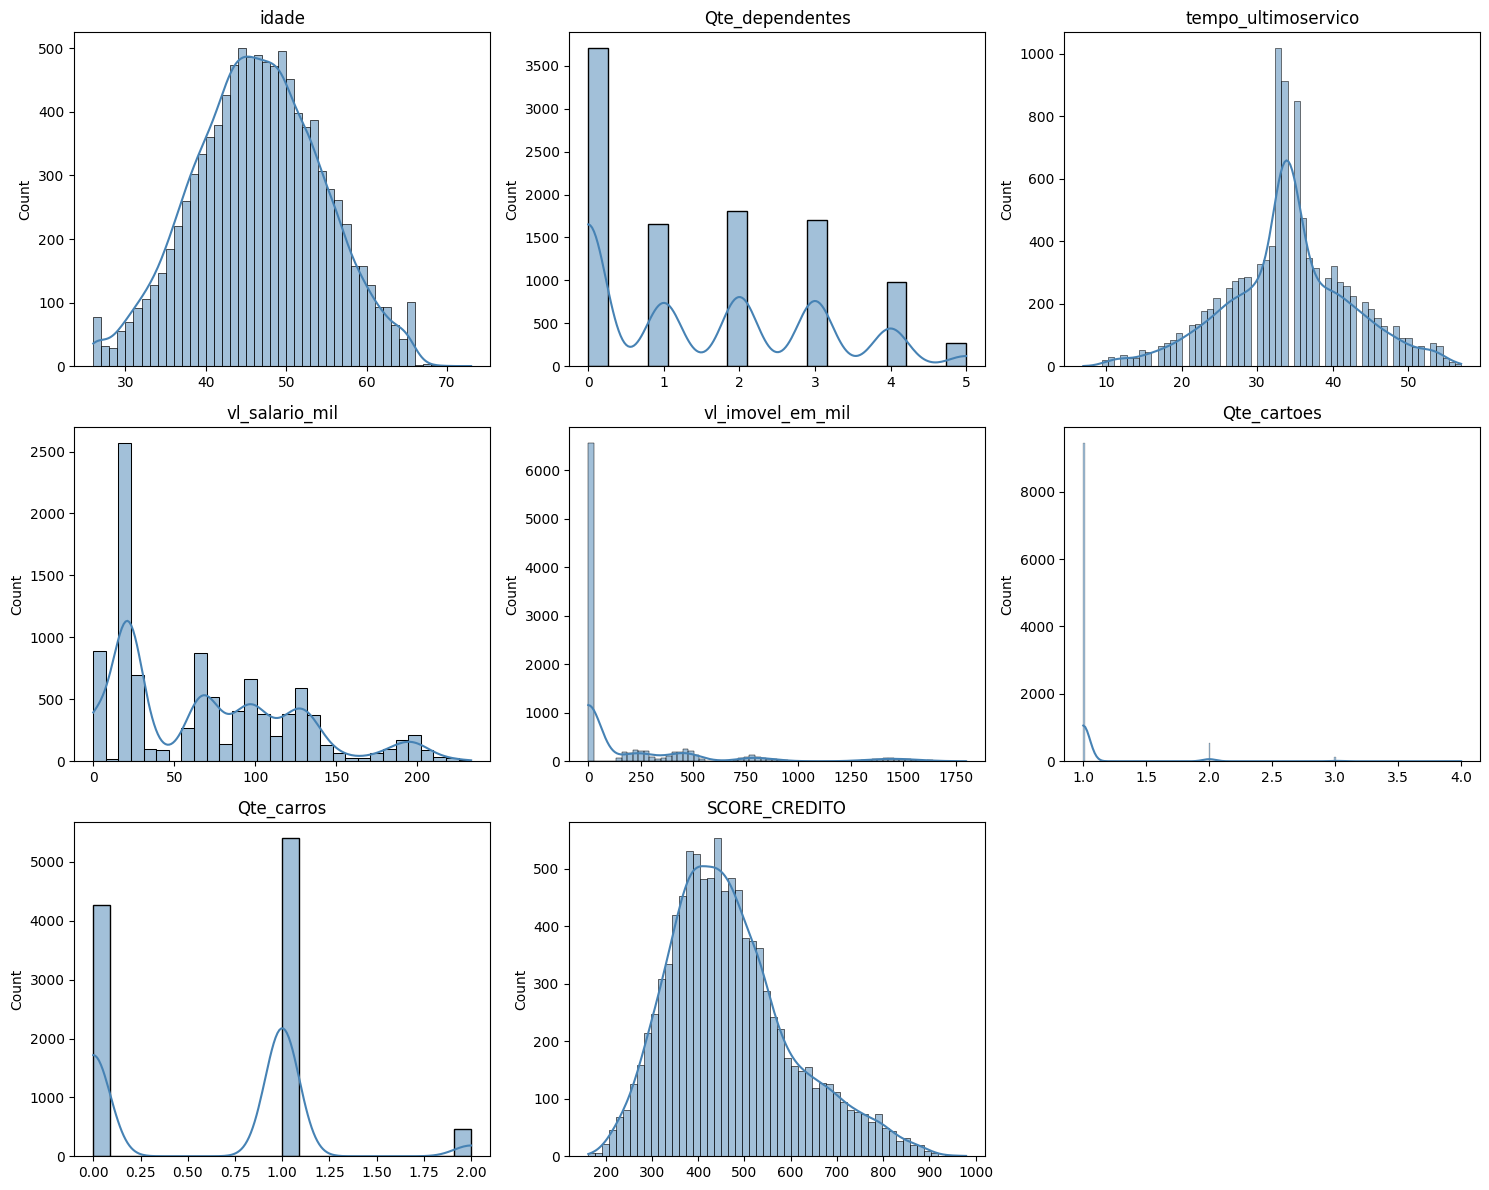

In [109]:
# Distribuição das variáveis quantitativas

colunas = df.select_dtypes(include="number").columns.drop(["id", "trabalha", "reg_moradia", "casa_propria"])

n = len(colunas)
n_cols = 3
n_linhas = (n + n_cols -1) // n_cols

fig, axes = plt.subplots(n_linhas, n_cols, figsize = (15, 4 * n_linhas))
axes = axes.flatten()

for i, col in enumerate(colunas):
    sns.histplot(df[col], kde = True, ax = axes[i], color = "steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for x in range(i + 1, len(axes)):
    fig.delaxes(axes[x])

plt.tight_layout()
plt.show();

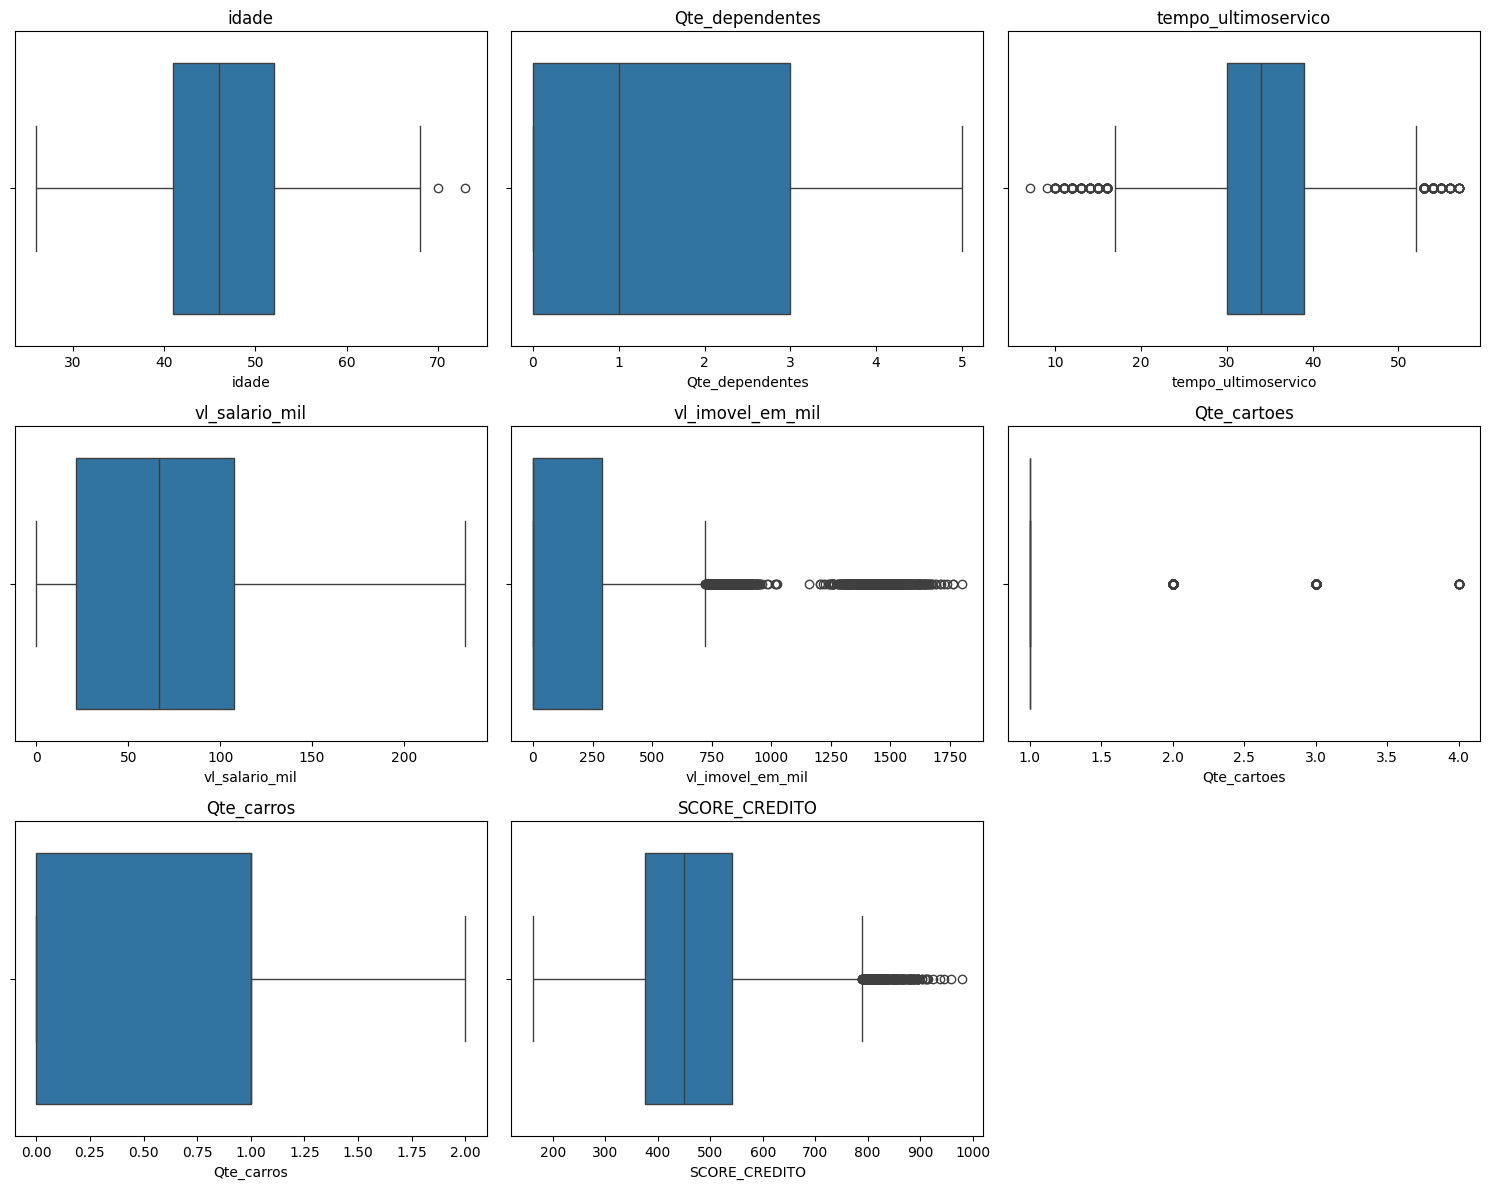

In [110]:
# Tratamento de outliers nas Quantitativas:
colunas_numericas = df.select_dtypes(include = "number").drop(columns = ["id", "trabalha", "casa_propria", "reg_moradia"]).columns
n = len(colunas_numericas)
n_cols = 3
n_linhas = (n + n_cols - 1) // n_cols   # arredonda pra cima

fig, axes = plt.subplots(n_linhas, n_cols, figsize=(15, 4 * n_linhas))
axes = axes.flatten()   # transforma a grade num vetor pra iterar fácil

for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(x=df[coluna], ax=axes[i])
    axes[i].set_title(coluna)

# remove os quadros vazios que sobram na grade
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [111]:
for col in ['vl_imovel_em_mil', 'tempo_ultimoservico', 'SCORE_CREDITO']:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQ = Q3 - Q1

    lim_15_sup, lim_3_sup = Q3 + 1.5*IQ, Q3 + 3*IQ
    lim_15_inf, lim_3_inf = Q1 - 1.5*IQ, Q1 - 3*IQ

    mod_sup = ((df[col] > lim_15_sup) & (df[col] <= lim_3_sup)).sum()
    ext_sup = (df[col] > lim_3_sup).sum()
    mod_inf = ((df[col] < lim_15_inf) & (df[col] >= lim_3_inf)).sum()
    ext_inf = (df[col] < lim_3_inf).sum()

    print(f"\n{col}:")
    print(f"  Superiores  -> moderados: {mod_sup}, extremos: {ext_sup}")
    print(f"  Inferiores  -> moderados: {mod_inf}, extremos: {ext_inf}")
    print(f"  TOTAL outliers (1.5×IQR): {mod_sup+ext_sup+mod_inf+ext_inf}")


vl_imovel_em_mil:
  Superiores  -> moderados: 533, extremos: 562
  Inferiores  -> moderados: 0, extremos: 0
  TOTAL outliers (1.5×IQR): 1095

tempo_ultimoservico:
  Superiores  -> moderados: 187, extremos: 0
  Inferiores  -> moderados: 240, extremos: 0
  TOTAL outliers (1.5×IQR): 427

SCORE_CREDITO:
  Superiores  -> moderados: 248, extremos: 0
  Inferiores  -> moderados: 0, extremos: 0
  TOTAL outliers (1.5×IQR): 248


In [112]:
print(df['vl_imovel_em_mil'].describe())
print("Zeros:", (df['vl_imovel_em_mil'] == 0).sum())
print("Assimetria:", df['vl_imovel_em_mil'].skew())
print("Assimetria tempo_ultimoservico:", df['tempo_ultimoservico'].skew())

count    10127.000000
mean       208.999111
std        378.495229
min          0.000000
25%          0.000000
50%          0.000000
75%        289.000000
max       1800.000000
Name: vl_imovel_em_mil, dtype: float64
Zeros: 6558
Assimetria: 2.179424667963753
Assimetria tempo_ultimoservico: -0.06049179350587253


In [117]:
# Transformação da variável Valor do imovel em log pela alta assimetria:

df['vl_imovel_log'] = np.log1p(df['vl_imovel_em_mil'])


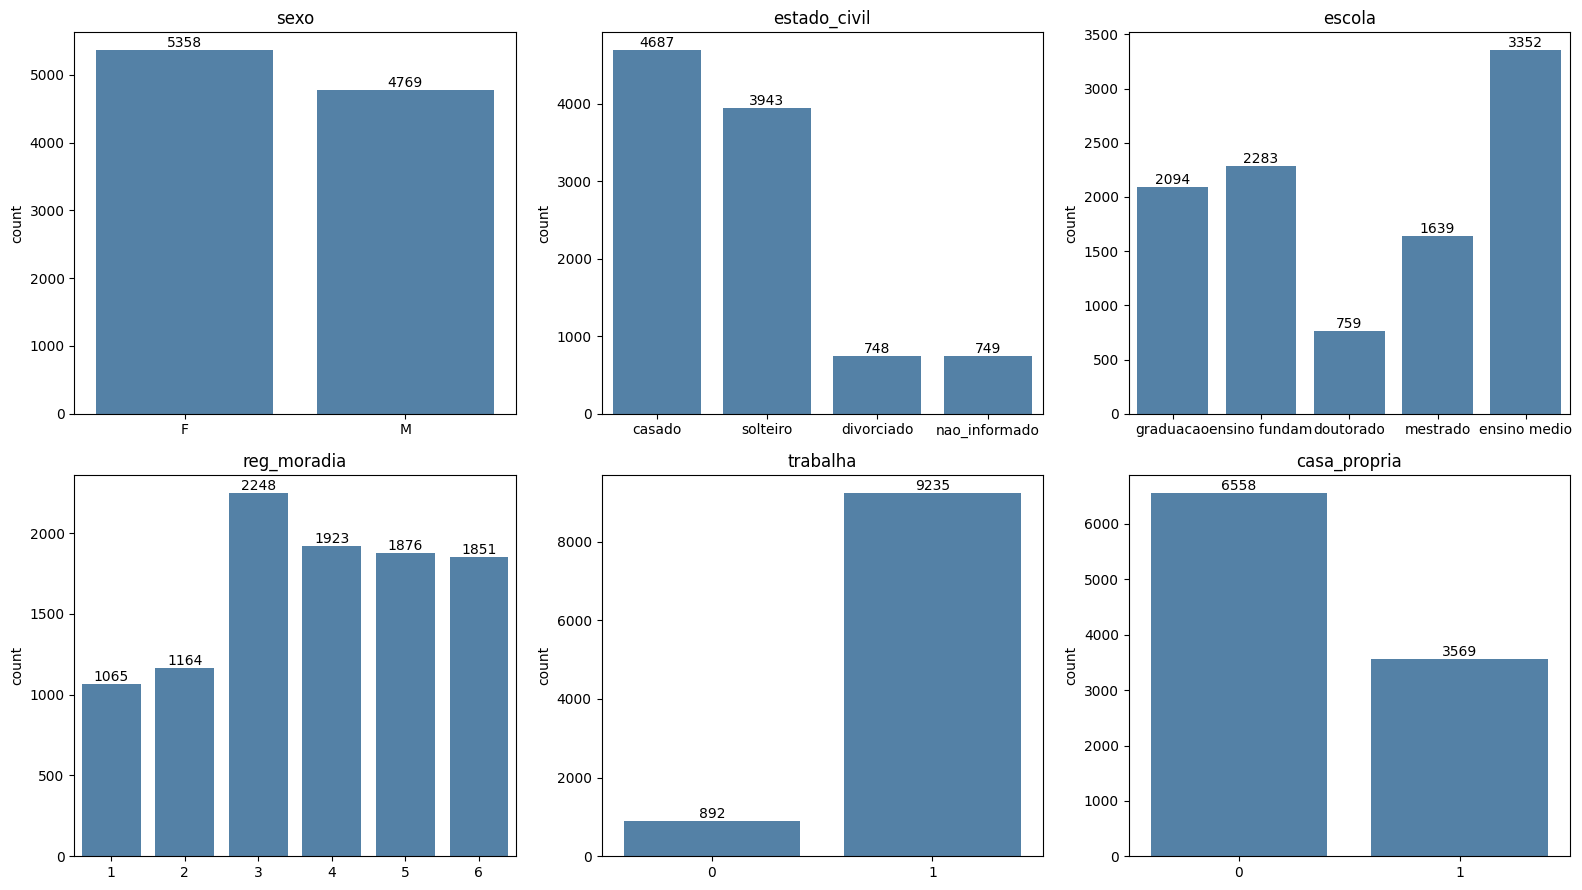

In [113]:
# Countplot para variáveis qualitativas:

categoricas = ['sexo', 'estado_civil', 'escola', 'reg_moradia',
               'trabalha', 'casa_propria']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df, x=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    # rótulo de contagem em cima de cada barra
    for container in axes[i].containers:
        axes[i].bar_label(container)

plt.tight_layout()
plt.show()

In [114]:
# Investigação dos valores NA em estado_civil:

print(df['estado_civil'].unique())
print((df['estado_civil'] == 'na').sum())
print(f"{(df['estado_civil'] == 'na').mean() * 100:.1f}%")

# Manter na pois seria uma perda muito grande da amostra

df['estado_civil'] = df['estado_civil'].replace('na', 'nao_informado')

<StringArray>
['casado', 'solteiro', 'divorciado', 'nao_informado']
Length: 4, dtype: str
0
0.0%


In [115]:
# Tratamento de nulos
df.isna().sum().sort_values(ascending=False)

id                     0
idade                  0
sexo                   0
estado_civil           0
escola                 0
Qte_dependentes        0
tempo_ultimoservico    0
trabalha               0
vl_salario_mil         0
reg_moradia            0
casa_propria           0
vl_imovel_em_mil       0
Qte_cartoes            0
Qte_carros             0
SCORE_CREDITO          0
dtype: int64

In [116]:

# id = código de identificação do usuário, representado por números inteiros
## Tipo: Qualitativa Nominal 
# idade = idade do cliente, representado por números inteiros
## Tipo: Quantitativa contínua
# sexo = define o sexo do cliente, string com duas opções: "M", "F"
## Tipo: 
# escola = Grau de escolaridade 
# Qte_dependentes = Número de dependentes associados ao cliente, representados por um número inteiro
# 

# Parte 2 - Correlação + Logística

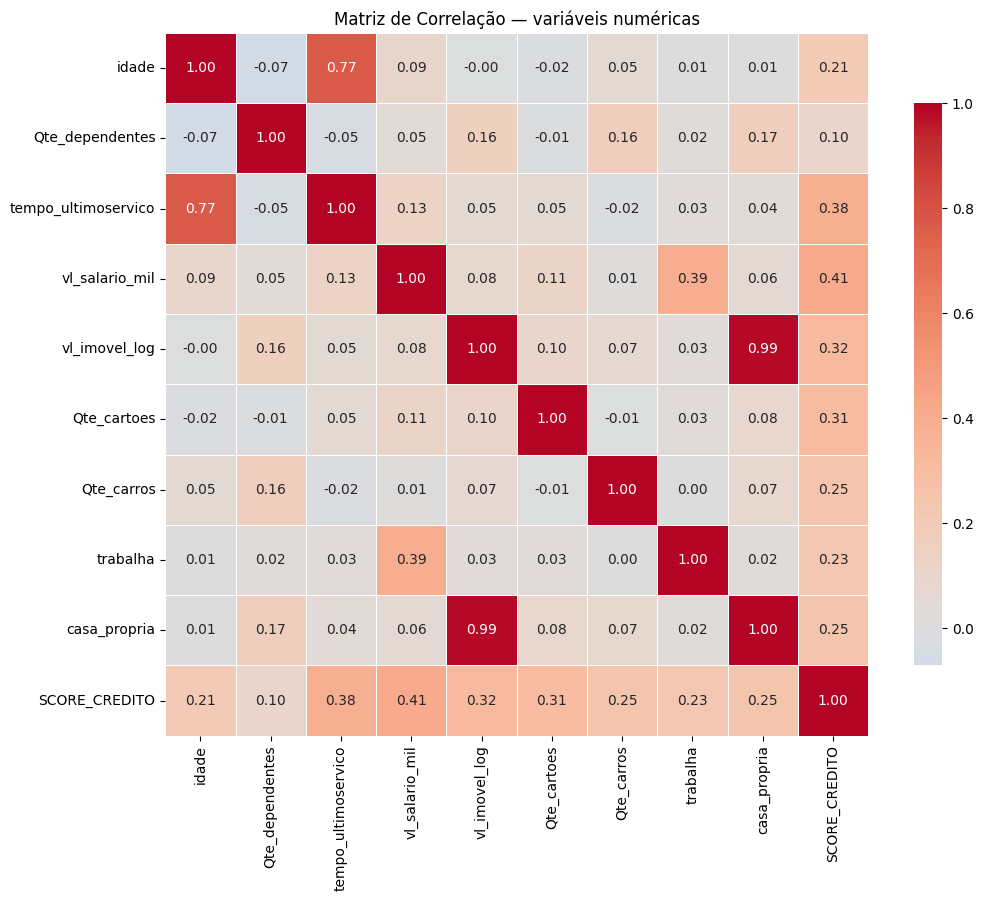

In [120]:
# Correlação com os dados quantitativos:

num_corr = ['idade', 'Qte_dependentes', 'tempo_ultimoservico',
            'vl_salario_mil', 'vl_imovel_log', 'Qte_cartoes',
            'Qte_carros', 'trabalha', 'casa_propria', 'SCORE_CREDITO']

corr = df[num_corr].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação — variáveis numéricas')
plt.tight_layout()
plt.show()

In [121]:
for col in ['sexo', 'estado_civil', 'escola', 'reg_moradia']:
    print(f"\n=== SCORE médio por {col} ===")
    print(df.groupby(col)['SCORE_CREDITO'].mean().sort_values())


=== SCORE médio por sexo ===
sexo
F    442.007309
M    500.388976
Name: SCORE_CREDITO, dtype: float64

=== SCORE médio por estado_civil ===
estado_civil
solteiro         450.747539
casado           476.336147
divorciado       494.775869
nao_informado    500.203965
Name: SCORE_CREDITO, dtype: float64

=== SCORE médio por escola ===
escola
ensino fundam    429.601743
graduacao        471.991681
ensino medio     477.587918
mestrado         486.558557
doutorado        510.085178
Name: SCORE_CREDITO, dtype: float64

=== SCORE médio por reg_moradia ===
reg_moradia
5    439.355034
6    439.872176
4    440.864552
3    453.724560
2    530.968588
1    591.919213
Name: SCORE_CREDITO, dtype: float64


In [123]:
print(df.groupby('reg_moradia')['SCORE_CREDITO'].mean().sort_values())

reg_moradia
5    439.355034
6    439.872176
4    440.864552
3    453.724560
2    530.968588
1    591.919213
Name: SCORE_CREDITO, dtype: float64


<Axes: xlabel='escola', ylabel='SCORE_CREDITO'>

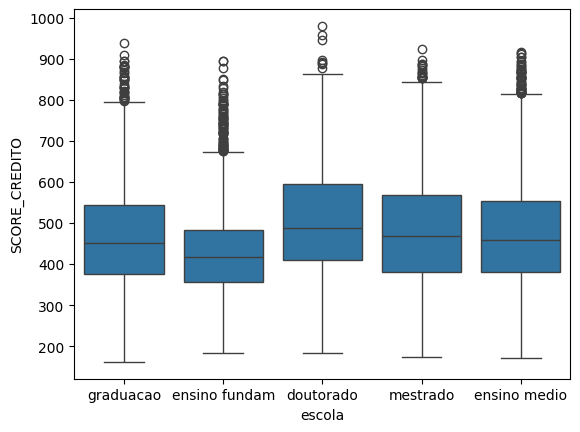

In [122]:
sns.boxplot(data=df, x='escola', y='SCORE_CREDITO')

In [106]:
# Matriz de correlação + relação das variáveis com o target
# Regressão logística no statsmodels (p-valores, coeficientes)
# Verificar as suposições do modelo de regressão
# Avaliação: acurácia, matriz de confusão, AUC-ROC

# Parte 3 - Árvore + Simulador

In [107]:
# Árvore de decisão (sklearn.tree)
# Avaliação da árvore (mesmas métricas da B, pra comparar de forma justa)
# Comparação logística vs. árvore: qual é melhor e por quê
# Simulador — função que recebe dados de um cliente e devolve o score